In [9]:
import matplotlib.pyplot as plt
import numpy as np

def draw_neural_network(a, b, c):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    input_neurons = a
    hidden_neurons = b
    output_neurons = c
    
    x_input, x_hidden, x_output = 0.1, 0.5, 0.9
    
    y_input = np.linspace(0.8, 0.2, input_neurons)
    y_hidden = np.linspace(0.8, 0.2, hidden_neurons)
    y_output = np.linspace(0.8, 0.2, output_neurons)
    
    def draw_neuron(x, y, color="skyblue"):
        circle = plt.Circle((x, y), 0.03, color=color, ec='black', lw=1)
        ax.add_patch(circle)
    
    for y in y_input:
        draw_neuron(x_input, y)

    for y in y_hidden:
        draw_neuron(x_hidden, y, color="lightgreen")

    for y in y_output:
        draw_neuron(x_output, y, color="salmon")
    
    for yi in y_input:
        for yh in y_hidden:
            ax.plot([x_input, x_hidden], [yi, yh], color="gray", linewidth=0.8)
    
    
    for yh in y_hidden:
        for yo in y_output:
            ax.plot([x_hidden, x_output], [yh, yo], color="gray", linewidth=0.8)
    
    
    ax.text(x_input, 0.95, f"Input Layer ({a})", fontsize=12, ha="center")
    ax.text(x_hidden, 0.95, f"Hidden Layer ({b})", fontsize=12, ha="center")
    ax.text(x_output, 0.95, f"Output Layer ({c})", fontsize=12, ha="center")
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    
    plt.show()



Initial parameters:
W1 =
 [[0.1 0.2 0.3]
 [0.4 0.5 0.6]]
b1 = [0. 0.]
W2 = [[0.7 0.8]]
b2 = [0.]
--------------------------------------------------


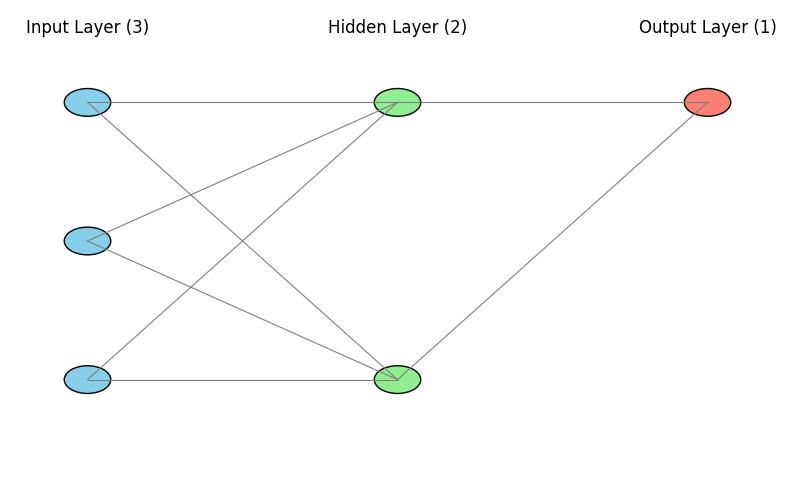

In [10]:
import numpy as np


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)


x = np.array([1.0, 2.0, 3.0])  # shape (3,)
y_true = 1.0                   # binary label

W1 = np.array([
    [0.1, 0.2, 0.3],  # to hidden neuron 1
    [0.4, 0.5, 0.6]   # to hidden neuron 2
])
b1 = np.array([0.0, 0.0])      # biases for hidden layer

W2 = np.array([[0.7, 0.8]])    # row vector shape (1,2)
b2 = np.array([0.0])           # bias for output


print("Initial parameters:")
print("W1 =\n", W1)
print("b1 =", b1)
print("W2 =", W2)
print("b2 =", b2)
print("-" * 50)


draw_neural_network(3, 2, 1)


In [11]:
x

array([1., 2., 3.])

z1 = W1[0]x+b
z

In [16]:
x*W1[0]

array([0.1, 0.4, 0.9])

In [34]:
z_hidden = W1 @ x + b1

In [29]:
print(z)

[1.4 3.2]


In [35]:
print(relu(z_hidden))

[1.4 3.2]


In [37]:
z_outer = W2 @ z_hidden + b2

In [38]:
z_outer

array([3.54])

In [41]:
sigmoid(z_outer)[0]

np.float64(0.9718047120298574)

In [40]:
import numpy as np

# ===== 1. Helper functions =====

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    # 1 where x > 0, else 0
    return (x > 0).astype(float)


# ===== 2. Define our tiny 3-2-1 network =====

# Input (3 features)
x = np.array([1.0, 2.0, 3.0])   # shape (3,)
y_true = 1.0                    # binary label

# Weights: Input (3) -> Hidden (2)
W1 = np.array([
    [0.1, 0.2, 0.3],   # to hidden neuron 1
    [0.4, 0.5, 0.6]    # to hidden neuron 2
])                     # shape (2,3)
b1 = np.array([0.0, 0.0])   # shape (2,)

# Weights: Hidden (2) -> Output (1)
W2 = np.array([[0.7, 0.8]])  # shape (1,2)
b2 = np.array([0.0])         # shape (1,)

print("Initial W1:\n", W1)
print("Initial W2:", W2)
print("-"*40)


# ===== 3. Forward pass =====

# Input -> Hidden
z1 = W1 @ x + b1        # shape (2,)
h = relu(z1)            # shape (2,)

# Hidden -> Output
z2 = W2 @ h + b2        # shape (1,)
y_hat = sigmoid(z2)[0]  # scalar

# Binary cross-entropy loss
loss = -(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))

print("Forward:")
print("x  =", x)
print("z1 =", z1, " (pre-activation hidden)")
print("h  =", h,  " (after ReLU)")
print("z2 =", z2[0], " (pre-activation output)")
print("y_hat =", y_hat, " (after sigmoid)")
print("loss  =", loss)
print("-"*40)


# ===== 4. Backward pass (1 training example) =====

lr = 0.1  # learning rate

# Output layer gradients
dz2 = y_hat - y_true          # dL/dz2, scalar
dW2 = dz2 * h                 # shape (2,)
db2 = dz2                     # scalar

# Backprop into hidden layer
dh = (W2.T * dz2).reshape(-1)   # shape (2,)
dz1 = dh * relu_derivative(z1)  # shape (2,)

# Gradients for W1, b1
dW1 = np.outer(dz1, x)        # (2,) x (3,) -> (2,3)
db1 = dz1                     # shape (2,)

print("Gradients:")
print("dz2:", dz2)
print("dW2:", dW2)
print("db2:", db2)
print("dh :", dh)
print("dz1:", dz1)
print("dW1:\n", dW1)
print("db1:", db1)
print("-"*40)


# ===== 5. Gradient descent update =====

W2_new = W2 - lr * dW2.reshape(1, 2)
b2_new = b2 - lr * db2

W1_new = W1 - lr * dW1
b1_new = b1 - lr * db1

print("Updated W2:", W2_new)
print("Updated b2:", b2_new)
print("Updated W1:\n", W1_new)
print("Updated b1:", b1_new)


Initial W1:
 [[0.1 0.2 0.3]
 [0.4 0.5 0.6]]
Initial W2: [[0.7 0.8]]
----------------------------------------
Forward:
x  = [1. 2. 3.]
z1 = [1.4 3.2]  (pre-activation hidden)
h  = [1.4 3.2]  (after ReLU)
z2 = 3.5399999999999996  (pre-activation output)
y_hat = 0.9718047120298574  (after sigmoid)
loss  = 0.028600408257058365
----------------------------------------
Gradients:
dz2: -0.02819528797014259
dW2: [-0.0394734  -0.09022492]
db2: -0.02819528797014259
dh : [-0.0197367  -0.02255623]
dz1: [-0.0197367  -0.02255623]
dW1:
 [[-0.0197367  -0.0394734  -0.0592101 ]
 [-0.02255623 -0.04511246 -0.06766869]]
db1: [-0.0197367  -0.02255623]
----------------------------------------
Updated W2: [[0.70394734 0.80902249]]
Updated b2: [0.00281953]
Updated W1:
 [[0.10197367 0.20394734 0.30592101]
 [0.40225562 0.50451125 0.60676687]]
Updated b1: [0.00197367 0.00225562]
